# Demo: DeepHit Competing Risks (MLP)

This notebook trains and evaluates a competing-risks DeepHit model on AAPL limit-order-book samples using an MLP backbone.

Input streams:
- LOB features from `entry_representation` with shape (20, 41)
- Toxicity features from `toxicity_representation` plus side channel with shape (20, 19)
- Combined model input shape (20, 60)

Event coding used in this notebook:
| Event | Code |
|------|------|
| CENSORED | 0 |
| FAVORABLE_FILL | 1 |
| TOXIC_FILL | 2 |

Workflow: load data, preprocess, train DeepHit, predict CIFs, and evaluate calibration/ranking metrics.

## 1. Import Required Libraries

In [31]:
from __future__ import annotations

import os
import sys
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from pycox.models import DeepHit
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from pycox.models.data import pair_rank_mat
from pycox.evaluation import EvalSurv

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.domain.enums import EventType

%matplotlib inline
print("PyTorch:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# CPU-only tuning: use available cores efficiently.
if device.type == "cpu":
    cpu_threads = max(1, os.cpu_count() or 1)
    torch.set_num_threads(cpu_threads)
    print(f"CPU threads configured: {cpu_threads}")

PyTorch: 2.10.0+cpu
Device: cpu
CPU threads configured: 8


## 2. Load and Explore the Dataset

The dataset is generated by `OrderTracker.process_stream` and labeled by `ExecutionCompetingRisksLabeler`.  
Key columns:
- **`duration_s`** - continuous lifetime of the virtual order (seconds)
- **`event_type`** - integer from `EventType` enum (0=censored, 1/2/3 = competing events)
- **`entry_representation`** - LOB snapshot sequence `(lookback, 2W+1)` stored as a nested list

In [32]:
DATASET_PATH = PROJECT_ROOT / "data" / "datasets" / "dataset_XNAS_ITCH_AAPL_mbo_20251001_20260101.parquet"

df_raw = pd.read_parquet(DATASET_PATH)
print("Shape:", df_raw.shape)
print("\nColumns:", list(df_raw.columns))
print("\nOriginal event type distribution:")
print(df_raw["event_type"].value_counts().sort_index().rename({v: v.name for v in EventType}))

Shape: (64000, 20)

Columns: ['best_ask_at_entry', 'best_ask_at_post_trade', 'best_bid_at_entry', 'best_bid_at_post_trade', 'duration_s', 'entry_representation', 'entry_time', 'event', 'event_time_bin', 'event_type', 'order_id', 'order_type', 'post_trade_adverse_move_bps', 'post_trade_recorded', 'post_trade_spread_bps', 'price', 'side', 'status_reason', 'toxicity_representation', 'volume']

Original event type distribution:
event_type
CENSORED            826
FAVORABLE_FILL    30311
TOXIC_FILL        32863
Name: count, dtype: int64


### 2a. Recode Event Types: Competing Fill Risks

We model **two competing risks** for fill outcomes:
- **Event 1 (FAVORABLE_FILL)**: original code `1`
- **Event 2 (TOXIC_FILL)**: original code `2`
- **Censored (0)**: original code `0`

This isolates fill quality by separating favorable and toxic fills in the hazard structure.

In [54]:
# Recode event types for competing-risks setup
df_raw["event_type_competing"] = df_raw["event_type"].copy()

label_map = {
    0: "CENSORED",
    1: "FAVORABLE_FILL",
    2: "TOXIC_FILL",
}

print("Recoded competing event distribution:")
event_counts = df_raw["event_type_competing"].value_counts().sort_index()
for code in sorted(event_counts.index):
    label = label_map.get(int(code), f"UNKNOWN_{code}")
    print(f"  {code}: {label:<30} - {event_counts[code]:>6} samples")

Recoded competing event distribution:
  0: CENSORED                       -    826 samples
  1: FAVORABLE_FILL                 -  30311 samples
  2: TOXIC_FILL                     -  32863 samples



Duration stats (seconds):
count    64000.000000
mean        12.606182
std         41.013965
min          0.000072
25%          0.527253
50%          1.802684
75%          6.376023
max        300.000000
Name: duration_s, dtype: float64


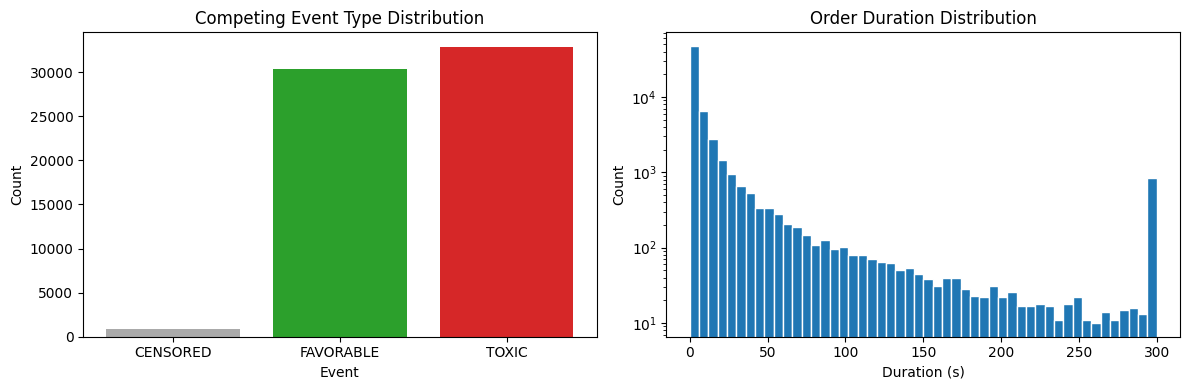

In [34]:
print("\nDuration stats (seconds):")
print(df_raw["duration_s"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Competing event distribution
event_counts = df_raw["event_type_competing"].value_counts().sort_index()
event_labels = ["CENSORED", "FAVORABLE", "TOXIC"]
bar_vals = [event_counts.get(0, 0), event_counts.get(1, 0), event_counts.get(2, 0)]
colors = ["#aaa", "#2ca02c", "#d62728"]
axes[0].bar(event_labels, bar_vals, color=colors)
axes[0].set_title("Competing Event Type Distribution")
axes[0].set_xlabel("Event")
axes[0].set_ylabel("Count")

# Duration distribution (log scale)
axes[1].hist(df_raw["duration_s"], bins=50, color="#1f77b4", edgecolor="white")
axes[1].set_title("Order Duration Distribution")
axes[1].set_xlabel("Duration (s)")
axes[1].set_ylabel("Count")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

## 3. Preprocess the Dataset

### 3a. Feature Extraction: LOB + Toxicity Dual Streams

Both `entry_representation` (LOB snapshots) and `toxicity_representation` (toxicity metrics) are `(lookback, features)` matrices covering the same temporal window.

**Processing:**
1. Extract LOB features `(N, 20, 41)` (raw market microstructure only)
2. Extract toxicity features `(N, 20, 18)` and append side as an extra channel -> `(N, 20, 19)`
3. Concatenate along feature axis -> `(N, 20, 60)` combined LOB+toxicity input
4. Keep each sample as a full 2D grid so the MLP can consume the entire lookback-feature structure

Final feature shape is `(N, 20, 60)`, used by a dual-branch MLP that flattens each stream's full 2D grid.

In [36]:
LOOKBACK_STEPS = 20

def extract_lob_features(df: pd.DataFrame, lookback_steps: int = LOOKBACK_STEPS) -> np.ndarray:
    """Extract fixed-length LOB features for MLP grid input.

    Returns shape (N, lookback_steps, 41).
    - entry_representation: array of (20,) where each element is shape (41,)
    - Final: (lookback, 41)

    If a sample is longer than lookback_steps, keep the most recent window.
    If shorter, left-pad with the first available snapshot.
    """
    rows = []
    for rep in df["entry_representation"]:
        # rep is array of shape (20,) where each element is shape (41,)
        # Stack into (20, 41)
        arr = np.stack([np.asarray(row, dtype=np.float32) for row in rep])

        if arr.shape[0] >= lookback_steps:
            arr = arr[-lookback_steps:]
        else:
            pad_len = lookback_steps - arr.shape[0]
            pad = np.repeat(arr[:1], repeats=pad_len, axis=0)
            arr = np.concatenate([pad, arr], axis=0)

        rows.append(arr)

    return np.stack(rows, axis=0)


def extract_toxicity_features(df: pd.DataFrame, lookback_steps: int = LOOKBACK_STEPS) -> np.ndarray:
    """Extract fixed-length toxicity features for MLP grid input, appending side as extra channel.

    Returns shape (N, lookback_steps, 19).
    - toxicity_representation: array of (20,) where each element is shape (18,)
    - side is appended: (lookback, 1)
    - Final: (lookback, 19)

    If a sample is longer than lookback_steps, keep the most recent window.
    If shorter, left-pad with the first available snapshot.
    """
    side_raw = df["side"]
    if np.issubdtype(side_raw.dtype, np.number):
        side_vals = side_raw.astype(np.float32).to_numpy()
    else:
        side_vals = (
            side_raw.astype(str)
            .str.upper()
            .map({"B": 1.0, "A": 0.0})
            .fillna(0.5)
            .astype(np.float32)
            .to_numpy()
        )

    rows = []
    for rep, side_val in zip(df["toxicity_representation"], side_vals):
        # rep is array of shape (20,) where each element is shape (18,)
        # Stack into (20, 18)
        arr = np.stack([np.asarray(row, dtype=np.float32) for row in rep])

        if arr.shape[0] >= lookback_steps:
            arr = arr[-lookback_steps:]
        else:
            pad_len = lookback_steps - arr.shape[0]
            pad = np.repeat(arr[:1], repeats=pad_len, axis=0)
            arr = np.concatenate([pad, arr], axis=0)

        side_col = np.full((arr.shape[0], 1), side_val, dtype=np.float32)
        arr_with_side = np.concatenate([arr, side_col], axis=1)
        rows.append(arr_with_side)

    return np.stack(rows, axis=0)


# Extract both LOB and toxicity features
X_lob = extract_lob_features(df_raw, lookback_steps=LOOKBACK_STEPS)
X_tox = extract_toxicity_features(df_raw, lookback_steps=LOOKBACK_STEPS)

# Concatenate along feature dimension
X_all = np.concatenate([X_lob, X_tox], axis=2)

Y_all = df_raw["duration_s"].values.astype(np.float32)             # continuous durations (seconds)
D_all = df_raw["event_type_competing"].values.astype(np.int64)      # 0=censored, 1=favorable, 2=toxic

print(f"LOB features shape       : {X_lob.shape}       - (N, lookback=20, LOB_features=41)")
print(f"Toxicity features shape  : {X_tox.shape}       - (N, lookback=20, toxicity_features=19)")
print(f"Combined features shape  : {X_all.shape}     - (N, lookback=20, combined_features=60)")
print(f"Duration vector shape    : {Y_all.shape}")
print(f"Event vector shape       : {D_all.shape}")
print(f"Unique event codes       : {sorted(np.unique(D_all).tolist())}")

LOB features shape       : (64000, 20, 41)       - (N, lookback=20, LOB_features=41)
Toxicity features shape  : (64000, 20, 19)       - (N, lookback=20, toxicity_features=19)
Combined features shape  : (64000, 20, 60)     - (N, lookback=20, combined_features=60)
Duration vector shape    : (64000,)
Event vector shape       : (64000,)
Unique event codes       : [0, 1, 2]


### 3b. Train / Validation / Test Split

In [37]:
SEED = 4718

# Day-boundary temporal split
# We extract the trading date for each order and choose the split points
# so that each partition starts cleanly at the beginning of a new day.

entry_ns = df_raw["entry_time"].values
dates = pd.to_datetime(entry_ns, unit="ns", utc=True).tz_convert("America/New_York").normalize()

unique_days = sorted(dates.unique())
n_days = len(unique_days)
print(f"Dataset spans {n_days} trading days: {unique_days[0].date()} to {unique_days[-1].date()}")

# Pick the day boundaries nearest to the 70 / 85 percentile of total rows
n = len(df_raw)
target_train_end = int(n * 0.70)
target_val_end   = int(n * 0.85)

# Cumulative row counts at the END of each day
day_end_idx = [(dates <= d).sum() - 1 for d in unique_days]   # last row index of each day

def _best_day_cut(target_row: int) -> int:
    """Return the index of the day whose END row is closest to target_row."""
    return min(range(n_days), key=lambda i: abs(day_end_idx[i] - target_row))

train_day_idx = _best_day_cut(target_train_end)
val_day_idx   = _best_day_cut(target_val_end)
train_day_idx = min(train_day_idx, n_days - 3)
val_day_idx   = max(train_day_idx + 1, min(val_day_idx, n_days - 2))

train_end = day_end_idx[train_day_idx] + 1
val_end   = day_end_idx[val_day_idx]   + 1

idx = np.arange(n)
train_mask = idx < train_end
val_mask   = (idx >= train_end) & (idx < val_end)
test_mask  = idx >= val_end

X_train, Y_train, D_train = X_all[train_mask], Y_all[train_mask], D_all[train_mask]
X_val,   Y_val,   D_val   = X_all[val_mask],   Y_all[val_mask],   D_all[val_mask]
X_test,  Y_test,  D_test  = X_all[test_mask],  Y_all[test_mask],  D_all[test_mask]

train_days = unique_days[:train_day_idx + 1]
val_days   = unique_days[train_day_idx + 1 : val_day_idx + 1]
test_days  = unique_days[val_day_idx + 1:]

print("Using full temporal splits without train/val subsampling:")
print(f"  Train samples: {len(X_train):,} over {len(train_days)} day(s)")
print(f"  Val samples  : {len(X_val):,} over {len(val_days)} day(s)")
print(f"  Test samples : {len(X_test):,} over {len(test_days)} day(s)")

Dataset spans 64 trading days: 2025-10-01 to 2025-12-31
Using full temporal splits without train/val subsampling:
  Train samples: 45,000 over 45 day(s)
  Val samples  : 9,000 over 9 day(s)
  Test samples : 10,000 over 10 day(s)


### 3c. Feature Normalisation

Standardise each feature using training-set mean and standard deviation (prevents data leakage).
For sequential data `(N, 20, F)`, normalization is applied feature-wise using train statistics over sample and time axes.


In [38]:
feat_mean = X_train.mean(axis=(0, 1), keepdims=True)  # Average over samples and time
feat_std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_np = ((X_train - feat_mean) / feat_std).astype(np.float32)
X_val_np   = ((X_val   - feat_mean) / feat_std).astype(np.float32)
X_test_np  = ((X_test  - feat_mean) / feat_std).astype(np.float32)

print(f"Normalized feature range - Train: [{X_train_np.min():.3f}, {X_train_np.max():.3f}]")

Normalized feature range - Train: [-113.860, 220.134]


### 3d. Discretise Continuous Durations

Following the reference implementation, we use PyCox's `LabTransDiscreteTime` for quantile-based binning.
Only uncensored events inform the grid construction.

In [39]:
class LabTransform(LabTransDiscreteTime):
    """Extends LabTransDiscreteTime to keep competing event codes (1..K)."""
    def transform(self, durations, events):
        durations, is_event = super().transform(durations, events > 0)
        events = events.astype("int64")
        events[is_event == 0] = 0
        return durations, events


NUM_TIME_STEPS = 30
if not (20 <= NUM_TIME_STEPS <= 40):
    raise ValueError("NUM_TIME_STEPS must be between 20 and 40.")

label_transform = LabTransform(NUM_TIME_STEPS, scheme="quantiles")

Y_train_disc, D_train_disc = label_transform.fit_transform(Y_train.copy(), D_train.copy())
Y_val_disc,   D_val_disc   = label_transform.transform(Y_val.copy(),   D_val.copy())

time_grid = label_transform.cuts
output_steps = len(time_grid)

print(f"Requested time steps : {NUM_TIME_STEPS}")
print(f"Actual time steps    : {output_steps}")
print(f"Time grid (seconds)  : {np.round(time_grid, 3)}")
print(f"Train event codes    : {sorted(np.unique(D_train_disc).tolist())}")

Requested time steps : 30
Actual time steps    : 30
Time grid (seconds)  : [0.0000e+00 2.7000e-02 5.8000e-02 9.2000e-02 1.2900e-01 1.7000e-01
 2.1600e-01 2.6700e-01 3.2100e-01 3.8200e-01 4.5000e-01 5.2700e-01
 6.0700e-01 7.0100e-01 8.0800e-01 9.2800e-01 1.0600e+00 1.2110e+00
 1.4020e+00 1.6160e+00 1.8750e+00 2.1810e+00 2.5680e+00 3.0730e+00
 3.7830e+00 4.7870e+00 6.3130e+00 9.0090e+00 1.6312e+01 3.0000e+02]
Train event codes    : [0, 1, 2]


### 3e. Build PyTorch Datasets

In [40]:
def make_tensors(X_np, Y_disc_np, D_disc_np):
    # Keep full (lookback, feature) grids; the model flattens each stream internally.
    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    Y = torch.tensor(Y_disc_np, dtype=torch.int64, device=device)
    D = torch.tensor(D_disc_np, dtype=torch.int64, device=device)
    return X, Y, D


X_train_t, Y_train_t, D_train_t = make_tensors(X_train_np, Y_train_disc, D_train_disc)
X_val_t, Y_val_t, D_val_t = make_tensors(X_val_np, Y_val_disc, D_val_disc)

train_data = list(zip(X_train_t, Y_train_t, D_train_t))
val_data = list(zip(X_val_t, Y_val_t, D_val_t))

print(f"Train tensor: X={tuple(X_train_t.shape)}, Y={tuple(Y_train_t.shape)}, D={tuple(D_train_t.shape)}")
print(f"Val tensor: X={tuple(X_val_t.shape)}, Y={tuple(Y_val_t.shape)}, D={tuple(D_val_t.shape)}")

Train tensor: X=(45000, 20, 60), Y=(45000,), D=(45000,)
Val tensor: X=(9000, 20, 60), Y=(9000,), D=(9000,)


## 4. Define the DeepHit Architecture

The competing-risks DeepHit model uses a **pure dual-branch MLP backbone** and outputs a joint cause-time tensor:
- **Dual input streams**: Concatenated LOB + toxicity features `(batch, 20, 60)`
  - LOB grid `(20, 41)` flattened to one vector per sample
  - Toxicity grid `(20, 19)` flattened to one vector per sample
- **Fusion MLP**: Concatenates stream embeddings and projects to `K x T` logits
- **Survival output**: `(batch, K, T)` where `K=2` competing events and `T` is discrete time steps
- **Event heads**: `FAVORABLE_FILL` and `TOXIC_FILL`

PyCox's `DeepHit` applies a joint softmax over the `K x T` logits to form a joint PMF over `(cause, time)` and derives cause-specific CIFs from that PMF.

## 5. Configure Training Parameters

In [41]:
# Hyperparameters
NUM_COMPETING_EVENTS = 2
EVENT_NAMES = ["FAVORABLE_FILL", "TOXIC_FILL"]
EVENT_CODES = [1, 2]

CPU_QUICK_MODE = device.type == "cpu"

# MLP architecture over full 2D grids
MLP_LOB_HIDDEN = 192 if CPU_QUICK_MODE else 320
MLP_TOX_HIDDEN = 96 if CPU_QUICK_MODE else 160
MLP_FUSION_HIDDEN = 160 if CPU_QUICK_MODE else 256
MLP_DROPOUT = 0.2

# DeepHit loss
ALPHA = 0.5
SIGMA = 0.1

# Optimisation
LEARNING_RATE = 5e-4
BATCH_SIZE = 512 if CPU_QUICK_MODE else 1024
NUM_EPOCHS = 100
EARLY_STOP_PATIENCE = 12
if not (80 <= NUM_EPOCHS <= 120):
    raise ValueError("NUM_EPOCHS must be between 80 and 120.")
if not (10 <= EARLY_STOP_PATIENCE <= 15):
    raise ValueError("EARLY_STOP_PATIENCE must be between 10 and 15.")

print("Configuration:")
for k, v in {
    "Competing events": NUM_COMPETING_EVENTS,
    "Event names": EVENT_NAMES,
    "Lookback steps": LOOKBACK_STEPS,
    "MLP LOB hidden": MLP_LOB_HIDDEN,
    "MLP TOX hidden": MLP_TOX_HIDDEN,
    "MLP fusion hidden": MLP_FUSION_HIDDEN,
    "MLP dropout": MLP_DROPOUT,
    "LR": LEARNING_RATE,
    "Batch size": BATCH_SIZE,
    "Epochs": NUM_EPOCHS,
    "Early stop patience": EARLY_STOP_PATIENCE,
}.items():

    print(f"  {k:<22}: {v}")

Configuration:
  Competing events      : 2
  Event names           : ['FAVORABLE_FILL', 'TOXIC_FILL']
  Lookback steps        : 20
  MLP LOB hidden        : 192
  MLP TOX hidden        : 96
  MLP fusion hidden     : 160
  MLP dropout           : 0.2
  LR                    : 0.0005
  Batch size            : 512
  Epochs                : 100
  Early stop patience   : 12


### 5a. Build Competing-Risks MLP

Define a dual-branch MLP backbone that outputs:

- **Survival logits**: shape `(batch, K, T)` for DeepHit competing risks (`K=2` fill outcomes, `T` time bins)
- **LOB branch**: consumes the full `(20, 41)` entry grid (flattened per sample)
- **Toxicity branch**: consumes the full `(20, 19)` toxicity grid (flattened per sample)

In [42]:
torch.manual_seed(SEED)

class DeepHitMLPCompeting(nn.Module):
    """Dual-branch MLP backbone for DeepHit competing risks.

    Input shape:  (batch, lookback_steps, num_features)
    Branch 1: (batch, lookback_steps, 41) LOB grid
    Branch 2: (batch, lookback_steps, 19) toxicity grid
    Output shape: (batch, num_events, num_time_steps)
    """
    def __init__(
        self,
        lookback_steps: int,
        lob_feature_dim: int,
        tox_feature_dim: int,
        num_events: int,
        num_time_steps: int,
        lob_hidden: int = 320,
        tox_hidden: int = 160,
        fusion_hidden: int = 256,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.lookback_steps = lookback_steps
        self.lob_feature_dim = lob_feature_dim
        self.tox_feature_dim = tox_feature_dim
        self.num_events = num_events
        self.num_time_steps = num_time_steps

        lob_input_dim = lookback_steps * lob_feature_dim
        tox_input_dim = lookback_steps * tox_feature_dim

        self.lob_encoder = nn.Sequential(
            nn.Linear(lob_input_dim, lob_hidden),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(lob_hidden),
            nn.Dropout(dropout),
        )

        self.tox_encoder = nn.Sequential(
            nn.Linear(tox_input_dim, tox_hidden),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(tox_hidden),
            nn.Dropout(dropout),
        )

        self.fusion_head = nn.Sequential(
            nn.Linear(lob_hidden + tox_hidden, fusion_hidden),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(fusion_hidden),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, num_events * num_time_steps),
        )

    def forward(self, x: torch.Tensor):
        x_lob = x[:, :, : self.lob_feature_dim]
        x_tox = x[:, :, self.lob_feature_dim : self.lob_feature_dim + self.tox_feature_dim]

        lob_repr = self.lob_encoder(x_lob.reshape(x.size(0), -1))
        tox_repr = self.tox_encoder(x_tox.reshape(x.size(0), -1))

        fused = torch.cat([lob_repr, tox_repr], dim=1)
        logits = self.fusion_head(fused)
        return logits.view(x.size(0), self.num_events, self.num_time_steps)


feature_dim = X_train_t.size(2)
lob_feature_dim = 41
tox_feature_dim = feature_dim - lob_feature_dim
if tox_feature_dim <= 0:
    raise ValueError(f"Invalid toxicity feature dimension: {tox_feature_dim}")

base_net = DeepHitMLPCompeting(
    lookback_steps=X_train_t.size(1),
    lob_feature_dim=lob_feature_dim,
    tox_feature_dim=tox_feature_dim,
    num_events=NUM_COMPETING_EVENTS,
    num_time_steps=output_steps,
    lob_hidden=MLP_LOB_HIDDEN,
    tox_hidden=MLP_TOX_HIDDEN,
    fusion_hidden=MLP_FUSION_HIDDEN,
    dropout=MLP_DROPOUT,
).to(device)

deephit_model = DeepHit(
    base_net,
    alpha=ALPHA,
    sigma=SIGMA,
    device=device,
    duration_index=time_grid,
 )

total_params = sum(p.numel() for p in base_net.parameters() if p.requires_grad)
print(f"Input shape      : {tuple(X_train_t.shape)}")
print(f"Lookback steps   : {X_train_t.size(1)}")
print(f"LOB feature dim  : {lob_feature_dim}")
print(f"TOX feature dim  : {tox_feature_dim}")
print(f"Total feature dim: {feature_dim}")
print(f"Output (K, T)    : ({NUM_COMPETING_EVENTS}, {output_steps})")
print(f"Trainable params : {total_params:,}")

Input shape      : (45000, 20, 60)
Lookback steps   : 20
LOB feature dim  : 41
TOX feature dim  : 19
Total feature dim: 60
Output (K, T)    : (2, 30)
Trainable params : 251,004


In [43]:
from torchsummary import summary
summary(base_net, input_size=(X_train_t.size(1), X_train_t.size(2)))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 192]         157,632
              ReLU-2                  [-1, 192]               0
       BatchNorm1d-3                  [-1, 192]             384
           Dropout-4                  [-1, 192]               0
            Linear-5                   [-1, 96]          36,576
              ReLU-6                   [-1, 96]               0
       BatchNorm1d-7                   [-1, 96]             192
           Dropout-8                   [-1, 96]               0
            Linear-9                  [-1, 160]          46,240
             ReLU-10                  [-1, 160]               0
      BatchNorm1d-11                  [-1, 160]             320
          Dropout-12                  [-1, 160]               0
           Linear-13                   [-1, 60]           9,660
Total params: 251,004
Trainable params:

## 6. Train the DeepHit Model

Training uses mini-batch gradient descent with the DeepHit competing-risks loss.  
Model parameters from the epoch with the **lowest validation loss** are retained.

In [44]:
# Data loading tuned for CPU/GPU differences.
if device.type == "cpu":
    train_loader = DataLoader(train_data, BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_data, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
else:
    train_loader = DataLoader(train_data, BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_data, BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

optimizer = torch.optim.Adam(base_net.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=LEARNING_RATE * 0.1
)

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_params = None
best_epoch_idx = None
epochs_no_improve = 0

# Training loop with early stopping.
for epoch in range(NUM_EPOCHS):
    base_net.train()
    epoch_loss = 0.0
    n_batches = 0

    for X_b, Y_b, D_b in train_loader:
        optimizer.zero_grad()

        surv_logits = base_net(X_b)

        rm = pair_rank_mat(Y_b.cpu().numpy(), D_b.cpu().numpy())
        rm_t = torch.tensor(rm, dtype=torch.int, device=device)
        loss = deephit_model.loss(surv_logits, Y_b, D_b, rm_t)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_loss = epoch_loss / n_batches

    base_net.eval()
    val_loss_total = 0.0
    n_val_batches = 0

    with torch.no_grad():
        for X_b, Y_b, D_b in val_loader:
            surv_logits = base_net(X_b)

            rm = pair_rank_mat(Y_b.cpu().numpy(), D_b.cpu().numpy())
            rm_t = torch.tensor(rm, dtype=torch.int, device=device)
            loss = deephit_model.loss(surv_logits, Y_b, D_b, rm_t)

            val_loss_total += loss.item()
            n_val_batches += 1

    val_loss = val_loss_total / n_val_batches

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch_idx = epoch
        best_params = deepcopy(base_net.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 2 == 0:
        print(
            f"Epoch {epoch+1:>3}/{NUM_EPOCHS}  "
            f"train={train_loss:.4f}  val={val_loss:.4f}  "
            f"(no improve: {epochs_no_improve})"
        )

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (val loss did not improve for {EARLY_STOP_PATIENCE} epochs)")
        break

base_net.load_state_dict(best_params)
print(f"\nBest val loss {best_val_loss:.4f} at epoch {best_epoch_idx + 1}")

Epoch   2/100  train=2.3400  val=2.2897  (no improve: 0)
Epoch   4/100  train=2.2860  val=2.2559  (no improve: 0)
Epoch   6/100  train=2.2620  val=2.2376  (no improve: 0)
Epoch   8/100  train=2.2355  val=2.2216  (no improve: 0)
Epoch  10/100  train=2.2294  val=2.2150  (no improve: 0)
Epoch  12/100  train=2.2097  val=2.2087  (no improve: 0)
Epoch  14/100  train=2.2090  val=2.2100  (no improve: 1)
Epoch  16/100  train=2.1971  val=2.2070  (no improve: 1)
Epoch  18/100  train=2.1899  val=2.2051  (no improve: 1)
Epoch  20/100  train=2.1790  val=2.2043  (no improve: 3)
Epoch  22/100  train=2.1728  val=2.2038  (no improve: 5)
Epoch  24/100  train=2.1653  val=2.2052  (no improve: 7)
Epoch  26/100  train=2.1588  val=2.2047  (no improve: 9)
Epoch  28/100  train=2.1555  val=2.2083  (no improve: 11)

Early stopping at epoch 29 (val loss did not improve for 12 epochs)

Best val loss 2.2025 at epoch 17


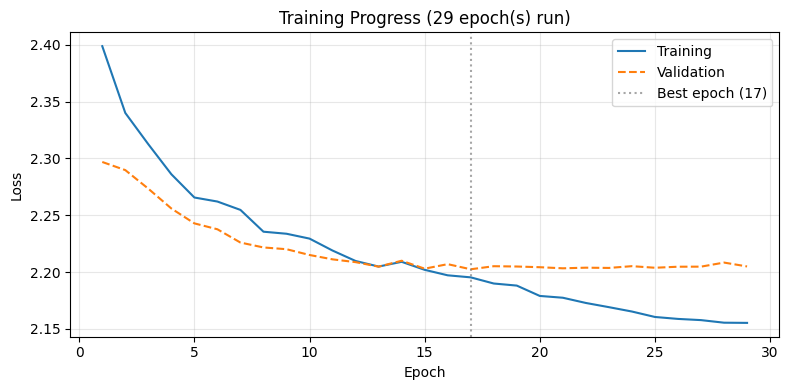


Best epoch 17:
  Train loss: 2.1953
  Val loss  : 2.2025


In [45]:
num_epochs_ran = min(len(train_losses), len(val_losses))
if num_epochs_ran == 0:
    raise RuntimeError("No training history found. Run training cell first.")

epochs = range(1, num_epochs_ran + 1)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(epochs, train_losses[:num_epochs_ran], label="Training", color="#1f77b4")
ax.plot(epochs, val_losses[:num_epochs_ran], "--", label="Validation", color="#ff7f0e")

best_epoch_display = (best_epoch_idx + 1) if best_epoch_idx is not None else None
if best_epoch_display is not None and 1 <= best_epoch_display <= num_epochs_ran:
    ax.axvline(
        best_epoch_display,
        color="grey",
        linestyle=":",
        alpha=0.7,
        label=f"Best epoch ({best_epoch_display})",
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Training Progress ({num_epochs_ran} epoch(s) run)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_idx = best_epoch_idx if best_epoch_idx is not None else num_epochs_ran - 1
print(f"\nBest epoch {best_epoch_display}:")
print(f"  Train loss: {train_losses[best_idx]:.4f}")
print(f"  Val loss  : {val_losses[best_idx]:.4f}")

## 7. Evaluate Model Performance

### 7a. Predict Cause-Specific CIFs on the Test Set

`deephit_model.predict_cif` returns an array of shape `(K, T, N)` where:
- `K` = number of competing events (`2`: favorable, toxic)
- `T` = discrete time steps
- `N` = number of test samples

In [46]:
base_net.eval()

# cif_test shape: (K, T, N_test)
cif_test = deephit_model.predict_cif(
    X_test_np.astype("float32"),
    batch_size=BATCH_SIZE,
    to_cpu=True,
    numpy=True,
)

print(f"CIF array shape: {cif_test.shape}   (K=events, T=time_steps, N=test_samples)")
print(f"CIF range: [{cif_test.min():.4f}, {cif_test.max():.4f}]")

print(f"\nFor test sample 0 at t={time_grid[-1]:.1f}s:")
total_fill_prob = 0.0
for k, name in enumerate(EVENT_NAMES):
    p = float(cif_test[k, -1, 0])
    total_fill_prob += p
    print(f"  CIF({name}) = {p:.4f}")
print(f"  CIF(ANY_FILL) = {total_fill_prob:.4f}")
print(f"  Survival      = {1.0 - total_fill_prob:.4f}")

CIF array shape: (2, 30, 10000)   (K=events, T=time_steps, N=test_samples)
CIF range: [0.0000, 0.8186]

For test sample 0 at t=300.0s:
  CIF(FAVORABLE_FILL) = 0.4339
  CIF(TOXIC_FILL) = 0.5381
  CIF(ANY_FILL) = 0.9720
  Survival      = 0.0280


### 7b. Distribution of Predicted Cause-Specific Fill Probabilities

Compare final-time CIF predictions for favorable and toxic risks across true outcome groups.

Test set composition:
  CENSORED      : 332
  FAVORABLE_FILL: 4898
  TOXIC_FILL    : 4770

Predicted final CIF means at t=300.0s:
  True FAVORABLE -> CIF(FAVORABLE): 0.4726
  True TOXIC     -> CIF(TOXIC)    : 0.5261


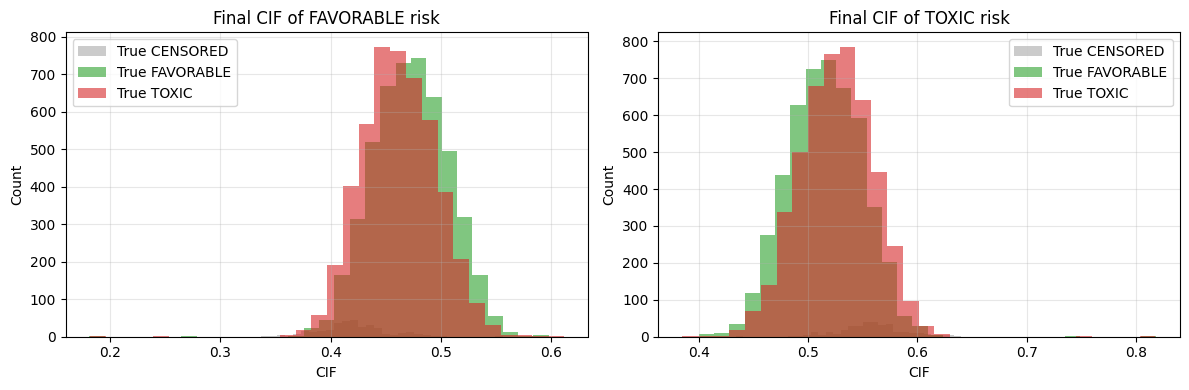

In [47]:
# Final-time cause-specific probabilities
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]

mask_cens = (D_test == 0)
mask_fav = (D_test == 1)
mask_tox = (D_test == 2)

print("Test set composition:")
print(f"  CENSORED      : {int(mask_cens.sum())}")
print(f"  FAVORABLE_FILL: {int(mask_fav.sum())}")
print(f"  TOXIC_FILL    : {int(mask_tox.sum())}")

print(f"\nPredicted final CIF means at t={time_grid[-1]:.1f}s:")
print(f"  True FAVORABLE -> CIF(FAVORABLE): {final_cif_fav[mask_fav].mean():.4f}")
print(f"  True TOXIC     -> CIF(TOXIC)    : {final_cif_tox[mask_tox].mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Favorable-risk distribution
axes[0].hist(final_cif_fav[mask_cens], bins=30, alpha=0.5, label="True CENSORED", color="#999999")
axes[0].hist(final_cif_fav[mask_fav], bins=30, alpha=0.6, label="True FAVORABLE", color="#2ca02c")
axes[0].hist(final_cif_fav[mask_tox], bins=30, alpha=0.6, label="True TOXIC", color="#d62728")
axes[0].set_title("Final CIF of FAVORABLE risk")
axes[0].set_xlabel("CIF")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Toxic-risk distribution
axes[1].hist(final_cif_tox[mask_cens], bins=30, alpha=0.5, label="True CENSORED", color="#999999")
axes[1].hist(final_cif_tox[mask_fav], bins=30, alpha=0.6, label="True FAVORABLE", color="#2ca02c")
axes[1].hist(final_cif_tox[mask_tox], bins=30, alpha=0.6, label="True TOXIC", color="#d62728")
axes[1].set_title("Final CIF of TOXIC risk")
axes[1].set_xlabel("CIF")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7c. Cause-Specific Concordance

Compute time-dependent concordance for each competing event by treating the other event as censoring for that cause-specific evaluation.

In [48]:
print("Time-dependent Concordance Index (Antolini) per competing event:")

ctd_scores = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    one_minus_cif_df = pd.DataFrame(
        1 - cif_test[k, :, :],
        index=time_grid,
    )

    ev = EvalSurv(
        one_minus_cif_df,
        Y_test,
        (D_test == event_code).astype(int),
        censor_surv="km",
    )

    ctd = ev.concordance_td("antolini")
    ctd_scores[event_name] = ctd
    print(f"  {event_name:<20}: C-td = {ctd:.4f}")

macro_ctd = float(np.mean(list(ctd_scores.values())))
print(f"\nMacro-average C-td: {macro_ctd:.4f}")

Time-dependent Concordance Index (Antolini) per competing event:
  FAVORABLE_FILL      : C-td = 0.6655
  TOXIC_FILL          : C-td = 0.5794

Macro-average C-td: 0.6225


### 7d. Integrated Brier Score

The integrated Brier score measures the average squared difference between predicted and observed survival probabilities over time.  
Lower scores indicate better calibration.

  FAVORABLE_FILL      : BS range [0.0000, 0.2450]
  TOXIC_FILL          : BS range [0.0000, 0.2488]

Integrated Brier Score (IBS) per event:
  FAVORABLE_FILL      : IBS = 0.2345
  TOXIC_FILL          : IBS = 0.2445

Macro-average IBS: 0.2395
Reference: IBS=0.25 for an uninformative model


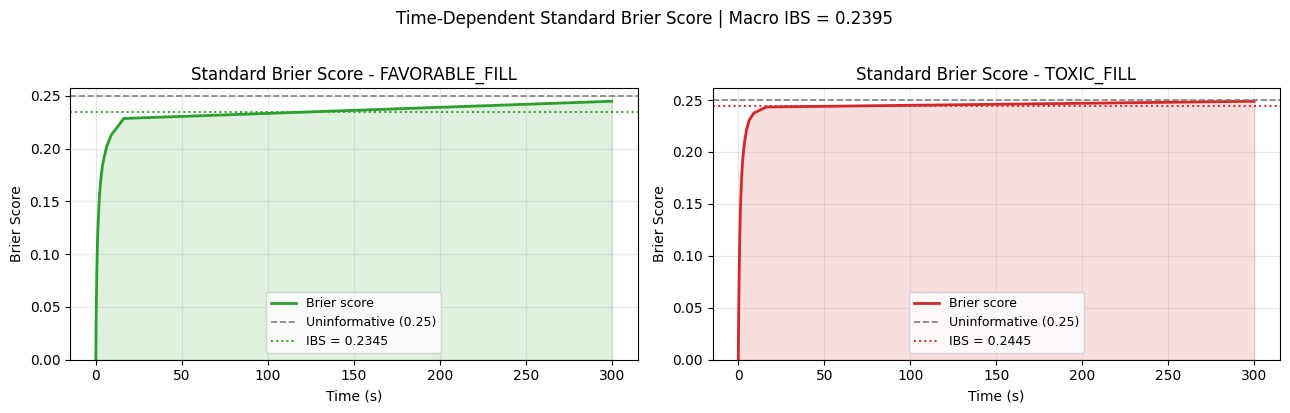

In [55]:
def standard_brier_score(
    durations: np.ndarray,
    events: np.ndarray,
    cif_k: np.ndarray,
    event_code: int,
    time_grid: np.ndarray,
) -> np.ndarray:
    """Compute standard Brier score for a specific cause at each time point."""
    T = len(time_grid)
    bs = np.zeros(T)

    for j, t in enumerate(time_grid):
        label = ((durations <= t) & (events == event_code)).astype(float)
        residual = (label - cif_k[j, :]) ** 2
        bs[j] = np.mean(residual)

    return bs

# Compute Brier score curves for each event.
bs_curves = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    bs_curves[event_name] = standard_brier_score(
        durations=Y_test,
        events=D_test,
        cif_k=cif_test[k],
        event_code=event_code,
        time_grid=time_grid,
)
    print(f"  {event_name:<20}: BS range [{bs_curves[event_name].min():.4f}, {bs_curves[event_name].max():.4f}]")

# Integrated Brier score (IBS) via trapezoidal integration.
t_min, t_max = time_grid[0], time_grid[-1]
_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

ibs_scores = {}
for event_name, bs_arr in bs_curves.items():
    ibs_scores[event_name] = _trapz(bs_arr, time_grid) / (t_max - t_min)

macro_ibs = float(np.mean(list(ibs_scores.values())))

print("\nIntegrated Brier Score (IBS) per event:")
for event_name, ibs in ibs_scores.items():
    print(f"  {event_name:<20}: IBS = {ibs:.4f}")
print(f"\nMacro-average IBS: {macro_ibs:.4f}")
print("Reference: IBS=0.25 for an uninformative model")

colors_bs = {"FAVORABLE_FILL": "#2ca02c", "TOXIC_FILL": "#d62728"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, (event_name, bs_arr) in zip(axes, bs_curves.items()):
    ibs_val = ibs_scores[event_name]
    color = colors_bs.get(event_name, "#1f77b4")

    ax.plot(time_grid, bs_arr, color=color, linewidth=2, label="Brier score")
    ax.fill_between(time_grid, bs_arr, alpha=0.15, color=color)
    ax.axhline(0.25, color="grey", linestyle="--", linewidth=1.2, label="Uninformative (0.25)")
    ax.axhline(ibs_val, color=color, linestyle=":", linewidth=1.4, label=f"IBS = {ibs_val:.4f}")
    ax.set_title(f"Standard Brier Score - {event_name}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Brier Score")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(f"Time-Dependent Standard Brier Score | Macro IBS = {macro_ibs:.4f}", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 7e. Visualize Competing CIFs for Sample Orders

Plot favorable-risk CIF, toxic-risk CIF, and implied survival for sample test orders.

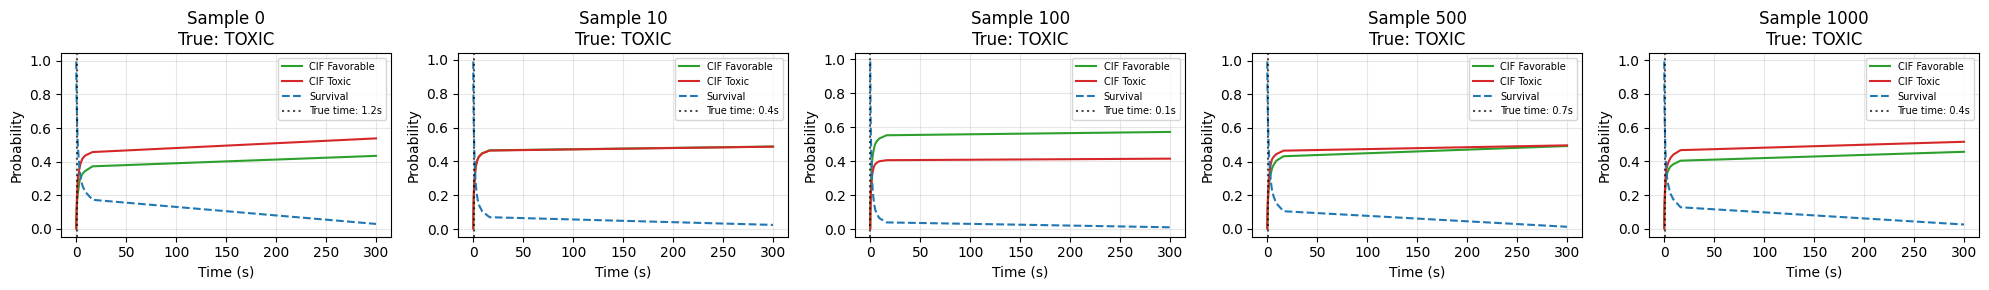

In [49]:
# Select a few sample orders to visualize
sample_indices = [0, 10, 100, 500, 1000]
sample_indices = [i for i in sample_indices if i < len(X_test)]

fig, axes = plt.subplots(1, len(sample_indices), figsize=(4 * len(sample_indices), 3))
if len(sample_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_indices):
    cif_fav = cif_test[0, :, idx]
    cif_tox = cif_test[1, :, idx]
    surv_curve = 1.0 - (cif_fav + cif_tox)

    true_time = Y_test[idx]
    true_event = int(D_test[idx])
    if true_event == 1:
        true_label = "FAVORABLE"
    elif true_event == 2:
        true_label = "TOXIC"
    else:
        true_label = "CENSORED"

    ax.plot(time_grid, cif_fav, label="CIF Favorable", color="#2ca02c")
    ax.plot(time_grid, cif_tox, label="CIF Toxic", color="#d62728")
    ax.plot(time_grid, surv_curve, label="Survival", color="#1f77b4", linestyle="--")
    ax.axvline(true_time, color="black", linestyle=":", alpha=0.7, label=f"True time: {true_time:.1f}s")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Probability")
    ax.set_title(f"Sample {idx}\nTrue: {true_label}")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7f. Event Classification Metrics and Stratified CIFs

Report event-classification quality (accuracy, precision, F1) using final-time probabilities, then compare average favorable/toxic CIF curves across true outcome groups.

In [50]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Use final-time probabilities to classify event type:
# 0 = CENSORED, 1 = FAVORABLE, 2 = TOXIC
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]
final_surv = np.clip(1.0 - (final_cif_fav + final_cif_tox), 0.0, 1.0)

proba_event = np.vstack([final_surv, final_cif_fav, final_cif_tox]).T  # (N, 3)
y_true = D_test.astype(int)
y_pred = proba_event.argmax(axis=1).astype(int)

In [56]:
# Final-time CIF diagnostics for event classification and censoring behavior.
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]
final_surv = np.clip(1.0 - (final_cif_fav + final_cif_tox), 0.0, 1.0)

# 1) Event-only classification: FAVORABLE vs TOXIC (exclude censored).
has_event_mask = (y_true == 1) | (y_true == 2)
y_true_events = y_true[has_event_mask]
final_cif_fav_events = final_cif_fav[has_event_mask]
final_cif_tox_events = final_cif_tox[has_event_mask]
y_pred_events = np.where(final_cif_fav_events > final_cif_tox_events, 1, 2)

event_labels = [1, 2]
event_names = ["FAVORABLE", "TOXIC"]

acc_events = accuracy_score(y_true_events, y_pred_events)
prec_macro_ev, rec_macro_ev, f1_macro_ev, _ = precision_recall_fscore_support(
    y_true_events, y_pred_events, labels=event_labels, average="macro", zero_division=0
)
prec_weighted_ev, rec_weighted_ev, f1_weighted_ev, _ = precision_recall_fscore_support(
    y_true_events, y_pred_events, labels=event_labels, average="weighted", zero_division=0
)
prec_cls_ev, rec_cls_ev, f1_cls_ev, support_cls_ev = precision_recall_fscore_support(
    y_true_events, y_pred_events, labels=event_labels, average=None, zero_division=0
)

print("Event-only classification (FAVORABLE vs TOXIC)")
print(f"Samples with events: {int(has_event_mask.sum())} / {len(y_true)} ({100 * has_event_mask.mean():.1f}%)")
print(f"Accuracy         : {acc_events:.4f}")
print(f"Precision (macro): {prec_macro_ev:.4f}")
print(f"Recall (macro)   : {rec_macro_ev:.4f}")
print(f"F1 (macro)       : {f1_macro_ev:.4f}")
print(f"Precision (wgt)  : {prec_weighted_ev:.4f}")
print(f"Recall (wgt)     : {rec_weighted_ev:.4f}")
print(f"F1 (wgt)         : {f1_weighted_ev:.4f}")

print("\nPer-class metrics:")
for i, name in enumerate(event_names):
    print(
        f"  {name:<10}  precision={prec_cls_ev[i]:.4f}  recall={rec_cls_ev[i]:.4f}  "
        f"f1={f1_cls_ev[i]:.4f}  n={int(support_cls_ev[i])}"
    )

cm_events = confusion_matrix(y_true_events, y_pred_events, labels=event_labels)
cm_events_df = pd.DataFrame(
    cm_events,
    index=[f"true_{n}" for n in event_names],
    columns=[f"pred_{n}" for n in event_names],
)
print("\nConfusion matrix (event samples only):")
display(cm_events_df)

# 2) Censoring diagnostics via final-time survival probability.
is_censored = y_true == 0
n_censored = int(is_censored.sum())
surv_prob_censored = final_surv[is_censored]
surv_prob_events = final_surv[has_event_mask]

avg_surv_censored = surv_prob_censored.mean()
avg_surv_events = surv_prob_events.mean()
threshold = 0.5
correct_cens = (surv_prob_censored > threshold).sum()

print("\nCensoring diagnostics")
print(f"Censored samples: {n_censored} / {len(y_true)} ({100 * is_censored.mean():.1f}%)")
print(f"Mean survival (censored): {avg_surv_censored:.4f}")
print(f"Mean survival (events)  : {avg_surv_events:.4f}")
print(f"Difference              : {avg_surv_censored - avg_surv_events:+.4f}")
print(f"Censored with survival > {threshold}: {int(correct_cens)} / {n_censored} ({100 * correct_cens / n_censored:.1f}%)")

# 3) Final-time summary.
print("\nFinal-time summary")
print(f"Accuracy (event-only)   : {acc_events:.4f}")
print(f"F1 macro (event-only)   : {f1_macro_ev:.4f}")
print(f"F1 weighted (event-only): {f1_weighted_ev:.4f}")
print(f"CIF(FAVORABLE): min={final_cif_fav.min():.4f}, max={final_cif_fav.max():.4f}, mean={final_cif_fav.mean():.4f}")
print(f"CIF(TOXIC)    : min={final_cif_tox.min():.4f}, max={final_cif_tox.max():.4f}, mean={final_cif_tox.mean():.4f}")
print(f"Survival      : min={final_surv.min():.4f}, max={final_surv.max():.4f}, mean={final_surv.mean():.4f}")

Event-only classification (FAVORABLE vs TOXIC)
Samples with events: 9668 / 10000 (96.7%)
Accuracy         : 0.5451
Precision (macro): 0.5709
Recall (macro)   : 0.5488
F1 (macro)       : 0.5086
Precision (wgt)  : 0.5715
Recall (wgt)     : 0.5451
F1 (wgt)         : 0.5068

Per-class metrics:
  FAVORABLE   precision=0.6172  recall=0.2689  f1=0.3746  n=4898
  TOXIC       precision=0.5247  recall=0.8287  f1=0.6426  n=4770

Confusion matrix (event samples only):


,pred_FAVORABLE,pred_TOXIC
true_FAVORABLE,1317,3581
true_TOXIC,817,3953



Censoring diagnostics
Censored samples: 332 / 10000 (3.3%)
Mean survival (censored): 0.0206
Mean survival (events)  : 0.0119
Difference              : +0.0087
Censored with survival > 0.5: 0 / 332 (0.0%)

Final-time summary
Accuracy (event-only)   : 0.5451
F1 macro (event-only)   : 0.5086
F1 weighted (event-only): 0.5068
CIF(FAVORABLE): min=0.1814, max=0.6114, mean=0.4658
CIF(TOXIC)    : min=0.3847, max=0.8186, mean=0.5220
Survival      : min=0.0000, max=0.0326, mean=0.0122
